In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC             #Kodumuzun içinde kullanacığımız metodları kütüphaneleri en başta toplayalım
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings("ignore")

le = LabelEncoder()
ohe = OneHotEncoder()

In [2]:
data = pd.read_csv("ilac.csv")
                                             #Üzerinde çalışacağımız veri setini alalım 
data.head() 

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [3]:
data.info()
print("*"*100)
categorical_col=[cols for cols in data.columns if data[cols].nunique() < 10]
print("Veri setimizin kategorik özellikleri : ",categorical_col)            # Datamızın bilgilerini alalım 
print("\n")                                                                 #Basit bir for ve şart ile datamızın kategorik ve   
numeric_col=[cols for cols in data.columns if data[cols].nunique() > 10]    # sayısal özelliklerini ayıralım 
print("Veri setimizin sayısal özellikleri : ",numeric_col)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB
****************************************************************************************************
Veri setimizin kategorik özellikleri :  ['Sex', 'BP', 'Cholesterol', 'Drug']


Veri setimizin sayısal özellikleri :  ['Age', 'Na_to_K']


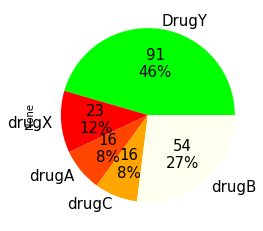

In [4]:
def label_function(val):
    return f'{val / 100 * len(data):.0f}\n{val:.0f}%'

labels = ["DrugY","drugX","drugA","drugC","drugB"]
data.groupby('Drug').size().plot(kind='pie', autopct=label_function, textprops={'fontsize': 15}, colors=['#00FF00','#FF0000','#FF4500','#FFA500',"#FFFFF0"],labels=labels)

plt.show()              #Bir fonksiyon ve pasta grafiği ile sınıfımızI görselleştirelim
                                    

In [5]:
data.Sex = le.fit_transform(data.Sex)    # Datamızdaki kategorik verileri sayısallaştıralım 

In [6]:
data.Cholesterol = le.fit_transform(data.Cholesterol)

In [7]:
BP =  data.iloc[:,2:3].values
BP = ohe.fit_transform(BP).toarray()
BPVeri = pd.DataFrame(data=BP,index=range(200),columns=["HIGH","LOW","NORMAL"])

In [8]:
data2 = data.iloc[:,0:5]
                                 #Bp verimiz datamızın ortasında olduğu için farklı bir dataya parça parça gönderip
                                 # tekrar birleştirelim 

In [9]:
data2 = data2.drop(["BP"],axis=1)  #Kategorik bp yi silelim 

In [10]:
dataSon = pd.concat([data2.iloc[:,0:2],BPVeri],axis=1) #İlk iki sütunumuzu ve sayısallaştırdığımız Bp yi başka bir dataya atalım

In [11]:
dataSon

,Age,Sex,HIGH,LOW,NORMAL
0,23,0,1.0,0.0,0.0
1,47,1,0.0,1.0,0.0
2,47,1,0.0,1.0,0.0
3,28,0,0.0,0.0,1.0
4,61,0,0.0,1.0,0.0
...,...,...,...,...,...
195,56,0,0.0,1.0,0.0
196,16,1,0.0,1.0,0.0
197,52,1,0.0,0.0,1.0
198,23,1,0.0,0.0,1.0


In [12]:
dataSon = pd.concat([dataSon,data2.iloc[:,2:5]],axis=1) #Bp den sonraki sütunlarıda getirelim 

In [13]:
dataSon

,Age,Sex,HIGH,LOW,NORMAL,Cholesterol,Na_to_K
0,23,0,1.0,0.0,0.0,0,25.355
1,47,1,0.0,1.0,0.0,0,13.093
2,47,1,0.0,1.0,0.0,0,10.114
3,28,0,0.0,0.0,1.0,0,7.798
4,61,0,0.0,1.0,0.0,0,18.043
...,...,...,...,...,...,...,...
195,56,0,0.0,1.0,0.0,0,11.567
196,16,1,0.0,1.0,0.0,0,12.006
197,52,1,0.0,0.0,1.0,0,9.894
198,23,1,0.0,0.0,1.0,1,14.020


In [14]:
dataSon = pd.concat([dataSon,data.iloc[:,5:6]],axis=1) #Son olarak sınıfımızıda getirelim 

In [15]:
dataSon

,Age,Sex,HIGH,LOW,NORMAL,Cholesterol,Na_to_K,Drug
0,23,0,1.0,0.0,0.0,0,25.355,DrugY
1,47,1,0.0,1.0,0.0,0,13.093,drugC
2,47,1,0.0,1.0,0.0,0,10.114,drugC
3,28,0,0.0,0.0,1.0,0,7.798,drugX
4,61,0,0.0,1.0,0.0,0,18.043,DrugY
...,...,...,...,...,...,...,...,...
195,56,0,0.0,1.0,0.0,0,11.567,drugC
196,16,1,0.0,1.0,0.0,0,12.006,drugC
197,52,1,0.0,0.0,1.0,0,9.894,drugX
198,23,1,0.0,0.0,1.0,1,14.020,drugX


In [16]:
data=dataSon.iloc[:,:] #Datamızı yeni haliyle güncelleyelim

In [17]:
data

,Age,Sex,HIGH,LOW,NORMAL,Cholesterol,Na_to_K,Drug
0,23,0,1.0,0.0,0.0,0,25.355,DrugY
1,47,1,0.0,1.0,0.0,0,13.093,drugC
2,47,1,0.0,1.0,0.0,0,10.114,drugC
3,28,0,0.0,0.0,1.0,0,7.798,drugX
4,61,0,0.0,1.0,0.0,0,18.043,DrugY
...,...,...,...,...,...,...,...,...
195,56,0,0.0,1.0,0.0,0,11.567,drugC
196,16,1,0.0,1.0,0.0,0,12.006,drugC
197,52,1,0.0,0.0,1.0,0,9.894,drugX
198,23,1,0.0,0.0,1.0,1,14.020,drugX


In [18]:
data.info()
print("*"*100)       #Eksik veri olup olmadığını görmek için datamıza bakalım (isnull().sum() da yapabilirdik ama geek duymadım)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int32  
 2   HIGH         200 non-null    float64
 3   LOW          200 non-null    float64
 4   NORMAL       200 non-null    float64
 5   Cholesterol  200 non-null    int32  
 6   Na_to_K      200 non-null    float64
 7   Drug         200 non-null    object 
dtypes: float64(4), int32(2), int64(1), object(1)
memory usage: 11.1+ KB
****************************************************************************************************


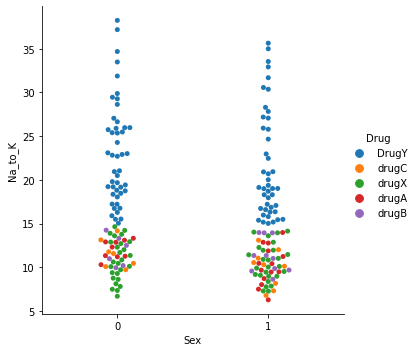

In [19]:
sns.catplot(x="Sex", y="Na_to_K", hue="Drug", kind="swarm",data=data)    #Feature larımızın sınıfımızın üstündeki 
                                                                     #etkilerini görebilmemiz için biraz görselleştirme yapalım

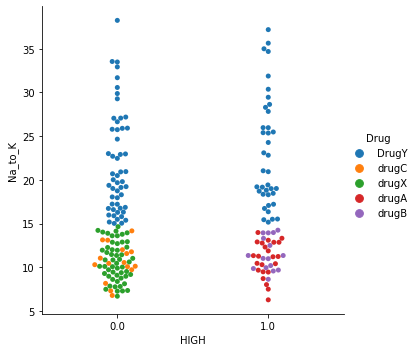

In [20]:
sns.catplot(x="HIGH", y="Na_to_K", hue="Drug", kind="swarm",data=data)

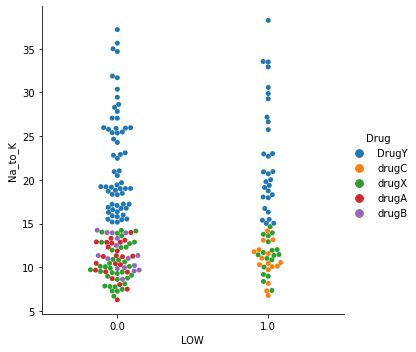

In [21]:
sns.catplot(x="LOW", y="Na_to_K", hue="Drug", kind="swarm",data=data)

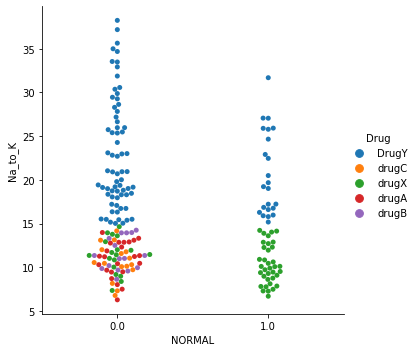

In [22]:
sns.catplot(x="NORMAL", y="Na_to_K", hue="Drug", kind="swarm",data=data)

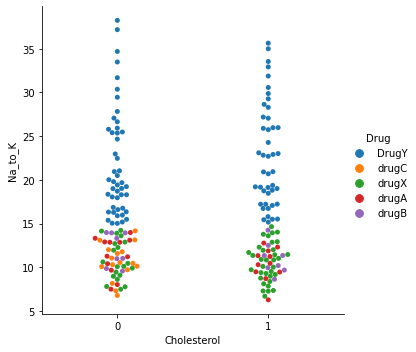

In [23]:
sns.catplot(x="Cholesterol", y="Na_to_K", hue="Drug", kind="swarm",data=data)

<AxesSubplot:xlabel='Na_to_K'>

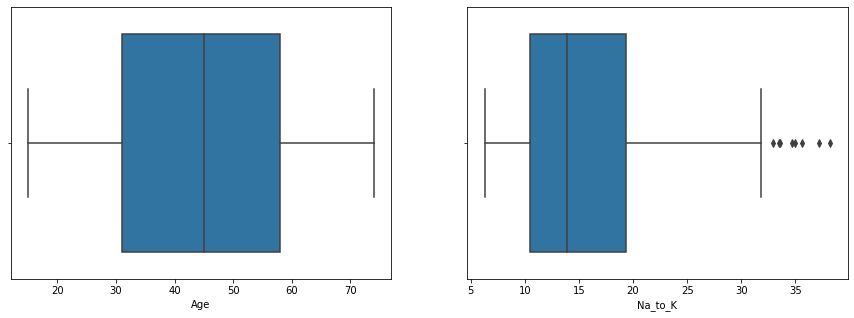

In [24]:
fig, (axis1,axis2) = plt.subplots(1,2,figsize=(15,5))
sns.boxplot(x=data["Age"],ax=axis1)                    #Sayısal featurelerimizin aykırı verileri olup olmadığına bakalım
sns.boxplot(x=data["Na_to_K"],ax=axis2)

In [25]:
def aykiriVeriBulma():   #Kodumuzdaki aykırı değerleri bulmak için fonksiyon yazalım 
    Q1 = data[[ 'Na_to_K']].quantile(0.25)
    Q3 = data[['Na_to_K']].quantile(0.75)     #BİR AYKIRI DEĞERE AYKIRI DEĞER MUAMELESİ YAPABİLMEK İÇİN BİR EŞİK BELİRLİYORUZ
    IQR = Q3-Q1
    
    altsinir= Q1-1.5*IQR #HER BİRİ İÇİN ALT SINIR Q1-1.5*IQR KADAR OLSUN 
    üstsinir= Q3+1.5*IQR #HER BİRİ İÇİN ÜST SINIR Q3+1.5*IQR KADAR OLSUN 
    
    aykiriVeriler = ((data[['Na_to_K']] < altsinir) | (data[['Na_to_K']] > üstsinir)) #altsıNırdan aşağıda veya üst sınırdan 
                                                                                      #yukarıda olan değerleri bulalım
                                                                                      #Yani aykırı değerlerimizi
    
    return aykiriVeriler
    

In [26]:
aykiri = aykiriVeriBulma()
aykiri.tail(20)   #Belirlediğimiz şartlara göre yazılan fonksiyon aykırı olan değerlere tru olmayanlara false diyecek

,Na_to_K
180,False
181,False
182,False
183,False
184,True
185,False
186,False
187,False
188,True
189,False


In [27]:
data.Na_to_K[aykiri.Na_to_K]   #Datanın aykiri Na_to_K feature undaki true olan verilerimizi bulmuş olduk 

24     33.486
96     38.247
98     35.639
128    33.542
131    32.922
184    37.188
188    34.997
194    34.686
Name: Na_to_K, dtype: float64

In [28]:
data[['Na_to_K']].mean() # Na_to_K feature unun ortalamasını bulduk 

Na_to_K    16.084485
dtype: float64

In [29]:
data.Na_to_K[aykiri.Na_to_K] =data.Na_to_K.mean()  # aykırı değerleri ortalama değerler ile değiştirmiş olduk 

In [30]:
data.Na_to_K[aykiri.Na_to_K] #kontrol ediyoruz

24     16.084485
96     16.084485
98     16.084485
128    16.084485
131    16.084485
184    16.084485
188    16.084485
194    16.084485
Name: Na_to_K, dtype: float64

<AxesSubplot:xlabel='Na_to_K'>

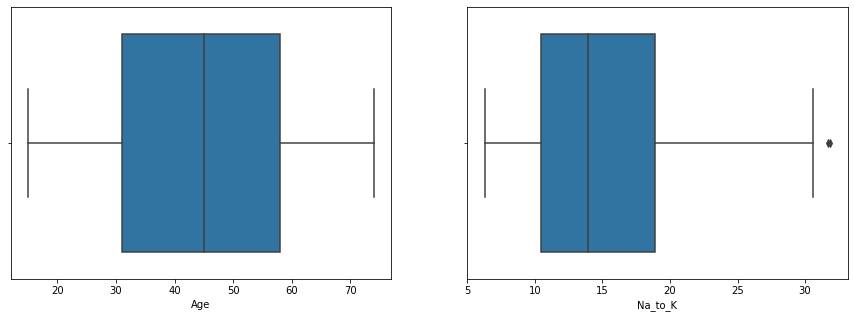

In [31]:
fig, (axis1,axis2) = plt.subplots(1,2,figsize=(15,5))
sns.boxplot(x=data["Age"],ax=axis1)                                #grafik üzerinden kontrol ediyoruz
sns.boxplot(x=data["Na_to_K"],ax=axis2)

In [32]:
data

,Age,Sex,HIGH,LOW,NORMAL,Cholesterol,Na_to_K,Drug
0,23,0,1.0,0.0,0.0,0,25.355,DrugY
1,47,1,0.0,1.0,0.0,0,13.093,drugC
2,47,1,0.0,1.0,0.0,0,10.114,drugC
3,28,0,0.0,0.0,1.0,0,7.798,drugX
4,61,0,0.0,1.0,0.0,0,18.043,DrugY
...,...,...,...,...,...,...,...,...
195,56,0,0.0,1.0,0.0,0,11.567,drugC
196,16,1,0.0,1.0,0.0,0,12.006,drugC
197,52,1,0.0,0.0,1.0,0,9.894,drugX
198,23,1,0.0,0.0,1.0,1,14.020,drugX


In [159]:
X = data.drop(["Drug"], axis=1)                   #Eğitim ve test datası olarak ayırıyoruz
y = data.Drug.values
                                                    
y=le.fit_transform(y) #sınıfımızı kategorik halden sayısal hale getiriyoruz

X_train, X_test, y_train, y_test =train_test_split(X, y, train_size=0.75,random_state=15)


In [160]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)                        #farklı modeller deneyerek en iyi doğruluk oranını bulmaya çalışalım
pred = logreg.predict(X_test)                                                           
print("Logistic Regression test doğruluk oranı = ", accuracy_score(y_test, pred)*100)
a_log = round(accuracy_score(y_test, pred) * 100, 2)

Logistic Regression test doğruluk oranı =  90.0


In [161]:
svc = SVC()
svc.fit(X_train, y_train)
pred = svc.predict(X_test)
print("Support Vector Machine test doğruluk oranı = ", accuracy_score(y_test, pred)*100)
a_svc = round(accuracy_score(y_test, pred) * 100, 2)

Support Vector Machine test doğruluk oranı =  70.0


In [162]:
sgd = SGDClassifier()
sgd.fit(X_train, y_train)
pred = sgd.predict(X_test)
print("Stochastic Gradient Descentt test doğruluk oranı = ", accuracy_score(y_test, pred)*100)
a_sgd = round(accuracy_score(y_test, pred) * 100, 2)

Stochastic Gradient Descentt test doğruluk oranı =  62.0


In [163]:
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
pred = decision_tree.predict(X_test)
print("Decision Tree test doğruluk oranı = ", accuracy_score(y_test, pred)*100)
a_decision_tree = round(accuracy_score(y_test, pred) * 100, 2)

Decision Tree test doğruluk oranı =  98.0


In [164]:
random_forest = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=2)
random_forest.fit(X_train, y_train)
pred = random_forest.predict(X_test)
random_forest.score(X_train, y_train)
print("Random Forest test doğruluk oranı = ", accuracy_score(y_test, pred)*100)
a_random_forest = round(accuracy_score(y_test, pred) * 100,2)

Random Forest test doğruluk oranı =  96.0


In [165]:

linear_svc = LinearSVC()
linear_svc.fit(X_train, y_train)
pred = linear_svc.predict(X_test)
print("Linear SVC test doğruluk oranı = ", accuracy_score(y_test, pred)*100)
a_linear_svc= round(accuracy_score(y_test, pred) * 100, 2)

Linear SVC test doğruluk oranı =  90.0


In [166]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
print("KNN test doğruluk oranı = ", accuracy_score(y_test, pred)*100)
a_knn = round(accuracy_score(y_test, pred) * 100, 2)

KNN test doğruluk oranı =  60.0


In [167]:
gaussian = GaussianNB()
gaussian.fit(X_train, y_train)
pred = gaussian.predict(X_test)
print("Gaussian Naive Bayes test doğruluk oranı = ", accuracy_score(y_test, pred)*100)
a_gaussian = round(accuracy_score(y_test, pred)* 100, 2)

Gaussian Naive Bayes test doğruluk oranı =  72.0


,model,score
7,Decision Tree,98.0
3,Random Forest,96.0
1,Logistic Regression,90.0
4,Linear SVC,90.0
2,Gaussian Naive Bayes,72.0
5,Support Vector Machines,70.0
6,Stochastic Gradient Decent,62.0
0,KNN,60.0


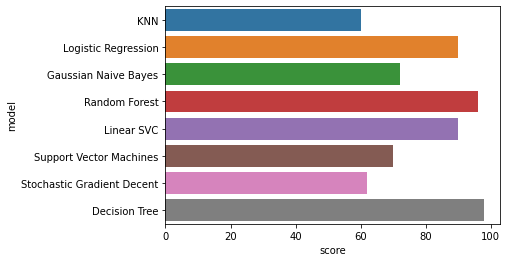

In [168]:
models = pd.DataFrame({
    'model': ['KNN','Logistic Regression', 
               'Gaussian Naive Bayes','Random Forest','Linear SVC', 
              'Support Vector Machines','Stochastic Gradient Decent','Decision Tree'],
    'score': [a_knn, a_log,  a_gaussian,                                                    #farklı yöntemlerle elde ettiğimiz
              a_random_forest, a_linear_svc,                                               #başarı oranlarını karşılaştıralım
              a_svc, a_sgd, a_decision_tree]})

sns.barplot(x='score', y='model', data=models)

models.sort_values(by='score', ascending=False)

In [122]:
deneme = X_test.head(5)

In [123]:
pred = decision_tree.predict(deneme) # en iyi orana sahip modellerimizin bir tanesini deneyelim

In [124]:
pred

array([0, 1, 0, 0, 4])

In [125]:
deneme = {'AGE':[25,38,27],
       'Sex':[1,0,1],
       "HIGH":[1.0,0.0,0.0],
          "LOW":[0.0,1.0,0.0],                  #Kendi yazacağımız rastgele değerlere sahip bir data oluşturalım 
          "NORMAL":[0.0,0.0,1.0],                # ve en iyi orana sahip modellerimizin bir tanesiyle deneyelim
         "Cholesterol":[1,0,1],
         "Na_to_K":[17.658,8.565,15.235]}

In [177]:
dataFrame = pd.DataFrame(deneme)
d=dataFrame.Na_to_K.values
c=dataFrame.Cholesterol.values

In [127]:
pred = decision_tree.predict(dataFrame)

In [128]:
pred

array([0, 3, 0])